# User-based Spatio‑Temporal Distance Analysis (GeoJSON + OSM + Local OSRM)

This notebook:

- Reads a contributed **GeoJSON** containing points with `created_by` and `created_at`.
- For each user, sorts points by time and computes **OSRM route distances** between **consecutive** points.
- Visualizes the local **OSM network (map.osm)** and the computed routes on an **interactive** map.
- Exports tables and plots to `outputs/` as **SVG** when `SAVE_SVG=True` in the corresponding cell.

> **Important:** All distance calculations are done using a **local OSRM server built from your `map.osm`** (not a public OSRM service).


In [3]:
# Cell 1 — Install required packages (run once)
import sys

!{sys.executable} -m pip install -q \
    geopandas shapely pyproj pandas numpy matplotlib folium osmnx networkx requests polyline ipywidgets

In [4]:
# Cell 2 — Imports
import json
import os
import subprocess
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import geopandas as gpd

import requests
import polyline as polyline_lib

import folium
import matplotlib.pyplot as plt

import osmnx as ox
import ipywidgets as widgets
from IPython.display import display, Markdown

In [5]:
# Cell 3 — Configuration (EDIT PATHS IF NEEDED)

GEOJSON_PATH = Path("data.geojson")
OSM_PATH     = Path("map.osm")

USER_COL = "created_by"
TIME_COL = "created_at"

# Columns that may exist in your GeoJSON
EVENT_TYPE_COL = "olay_turu_adi"
PHOTO_COL      = "photo_urls"
CIG_EVENT_NAME = "Cigarette Butt"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OSRM_ENDPOINTS = {
    "Car":  "http://127.0.0.1:5000",
    "Bike": "http://127.0.0.1:5001",
    "Foot": "http://127.0.0.1:5002",
}

MIN_DISTANCE_THRESHOLD = 250.0

print("GeoJSON:", GEOJSON_PATH.resolve())
print("OSM:", OSM_PATH.resolve())
print("Outputs:", OUTPUT_DIR.resolve())

GeoJSON: C:\Users\USER\OneDrive\Resimler\Masaüstü\ISPRS_PROJECTS\DiDe\Github-DiDe\Analysis\data.geojson
OSM: C:\Users\USER\OneDrive\Resimler\Masaüstü\ISPRS_PROJECTS\DiDe\Github-DiDe\Analysis\map.osm
Outputs: C:\Users\USER\OneDrive\Resimler\Masaüstü\ISPRS_PROJECTS\DiDe\Github-DiDe\Analysis\outputs


In [6]:
# Cell 4 — Read GeoJSON and print it

if not GEOJSON_PATH.exists():
    raise FileNotFoundError(f"GeoJSON file not found: {GEOJSON_PATH.resolve()}")

gdf = gpd.read_file(GEOJSON_PATH)

# Ensure point geometry and CRS
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)
else:
    gdf = gdf.to_crs(epsg=4326)

display(gdf.head(20))
print("\nColumns:", list(gdf.columns))
print("CRS:", gdf.crs)


,olay_id,olay_turu_id,olay_turu_adi,olay_turu_good,aciklama,photo_urls,video_urls,created_by,created_by_id,created_at,geometry
0,512,3,Cigarette Butt,False,Cigarette butts and an almost full rubbish bun...,/uploads/1765258806874_rvthghwrek.jpg,,yusragnd,13,2025-12-09 05:41:10.658000+00:00,POINT (32.73036 39.86888)
1,511,3,Cigarette Butt,False,Cigarette butts in front of the Geomatics Engi...,/uploads/1765258687466_viwpbrva53.jpg,,53,27,2025-12-09 05:38:55.460000+00:00,POINT (32.73361 39.86563)
2,510,1,Rubbish bin,True,“Trash bin in front of the Geomatics Engineeri...,/uploads/1765258617632_va6gvfedlu.jpg,,53,27,2025-12-09 05:37:34.242000+00:00,POINT (32.73353 39.86562)
3,509,3,Cigarette Butt,False,“Cigarette butts in front of the Geomatics bui...,/uploads/1765257102874_mzsww36lxp.jpg,,heis,25,2025-12-09 05:12:32.031000+00:00,POINT (32.73374 39.86559)
4,508,2,Recycle bin,True,Recycling bin in front of the Geomatics Engine...,/uploads/1765257062200_xl3thixj9.jpg,,heis,25,2025-12-09 05:11:16.131000+00:00,POINT (32.73368 39.8654)
5,507,2,Recycle bin,True,Recycling bin at the entrance of the Faculty o...,/uploads/1765256858509_b1dc52gq9ed.jpg,,heis,25,2025-12-09 05:07:48.251000+00:00,POINT (32.73322 39.86438)
6,506,2,Recycle bin,True,,/uploads/1765214223678_s7zolb0cje.jpg,,kaankaan1,42,2025-12-08 17:17:07.063000+00:00,POINT (32.72934 39.87034)
7,505,1,Rubbish bin,True,,/uploads/1765214099837_vpbda1xog19.jpg,,kaankaan1,42,2025-12-08 17:15:00.898000+00:00,POINT (32.73007 39.8688)
8,504,2,Recycle bin,True,,/uploads/1765213980314_whpdvtelxe.jpg,,kaankaan1,42,2025-12-08 17:12:33.835000+00:00,POINT (32.73081 39.86891)
9,503,2,Recycle bin,True,,/uploads/1765213879659_0se5jg3mqgxf.jpg,,kaankaan1,42,2025-12-08 17:11:21.528000+00:00,POINT (32.73079 39.87053)



Columns: ['olay_id', 'olay_turu_id', 'olay_turu_adi', 'olay_turu_good', 'aciklama', 'photo_urls', 'video_urls', 'created_by', 'created_by_id', 'created_at', 'geometry']
CRS: EPSG:4326


In [7]:
# Cell 5 — List unique users (from created_by) as a single-column table

SAVE_SVG = True  # <- set False to disable exporting this table as SVG

if USER_COL not in gdf.columns:
    raise KeyError(f"'{USER_COL}' column not found in GeoJSON. Columns are: {list(gdf.columns)}")

users = sorted(pd.Series(gdf[USER_COL].dropna().astype(str).unique()).tolist())
df_users = pd.DataFrame({"username": users})

display(df_users)


,username
0,0037
1,006
2,024
3,028
4,16
5,1Arca
6,207
7,216
8,42
9,528


In [ ]:
# Cell 6 — Read map.osm and show the OSM network on an interactive map
import folium

if not OSM_PATH.exists():
    raise FileNotFoundError(f"OSM file not found: {OSM_PATH.resolve()}")

G = ox.graph_from_xml(OSM_PATH, simplify=True)
edges = ox.graph_to_gdfs(G, nodes=False)

centroid = edges.unary_union.centroid
m_osm = folium.Map(location=[centroid.y, centroid.x], zoom_start=14, tiles="cartodbpositron")

for _, row in edges.iterrows():
    coords = [(lat, lon) for lon, lat in row.geometry.coords]
    folium.PolyLine(coords, weight=2, color="#333333", popup=row.get("name", "")).add_to(m_osm)

display(m_osm)

C:\Users\USER\AppData\Local\Temp\ipykernel_10772\1917745881.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = edges.unary_union.centroid


In [ ]:
# Cell 7 — Build & start LOCAL OSRM servers from map.osm (Car/Bike/Foot)
#
# This cell uses Docker (recommended). It:
# 1) builds OSRM data for each profile from your map.osm
# 2) starts three osrm-routed containers on ports 5000/5001/5002
#
# Requirements:
# - Docker installed and running (Docker Desktop on Windows/Mac, docker on Linux)
#
# If you already run OSRM yourself, you can skip this cell — just ensure the endpoints in OSRM_ENDPOINTS are reachable.

SAVE_LOGS = True  # saves build logs into outputs/osrm_logs/

OSRM_WORKDIR = OUTPUT_DIR / "osrm"
OSRM_WORKDIR.mkdir(parents=True, exist_ok=True)
LOG_DIR = OUTPUT_DIR / "osrm_logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

def _run(cmd: List[str], check=True) -> subprocess.CompletedProcess:
    return subprocess.run(cmd, check=check, capture_output=True, text=True)

def docker_available() -> bool:
    try:
        _run(["docker", "version"], check=True)
        return True
    except Exception:
        return False

def osrm_up(url: str) -> bool:
    try:
        r = requests.get(url.rstrip("/") + "/health", timeout=1.5)
        return r.status_code == 200
    except Exception:
        return False

def ensure_osrm_profile(profile_name: str, lua_in_container: str, port: int) -> None:
    # Each profile gets its own folder (so outputs don't overwrite each other)
    prof_dir = OSRM_WORKDIR / profile_name.lower()
    prof_dir.mkdir(parents=True, exist_ok=True)

    # Copy map.osm into the profile folder (OSRM expects the input in the mounted directory)
    osm_dst = prof_dir / "map.osm"
    if not osm_dst.exists():
        osm_dst.write_bytes(OSM_PATH.read_bytes())

    # Build OSRM dataset (extract + partition + customize)
    # (If map.osrm exists, we assume it's already built.)
    map_osrm = prof_dir / "map.osrm"
    if not map_osrm.exists():
        print(f"Building OSRM data for {profile_name} ...")
        extract_cmd = ["docker", "run", "--rm", "-t",
                       "-v", f"{prof_dir.resolve()}:/data",
                       "osrm/osrm-backend",
                       "osrm-extract", "-p", lua_in_container, "/data/map.osm"]
        part_cmd   = ["docker", "run", "--rm", "-t",
                      "-v", f"{prof_dir.resolve()}:/data",
                      "osrm/osrm-backend",
                      "osrm-partition", "/data/map.osrm"]
        cust_cmd   = ["docker", "run", "--rm", "-t",
                      "-v", f"{prof_dir.resolve()}:/data",
                      "osrm/osrm-backend",
                      "osrm-customize", "/data/map.osrm"]

        for name, cmd in [("extract", extract_cmd), ("partition", part_cmd), ("customize", cust_cmd)]:
            proc = _run(cmd, check=True)
            if SAVE_LOGS:
                (LOG_DIR / f"{profile_name.lower()}_{name}.log").write_text(proc.stdout + "\n" + proc.stderr, encoding="utf-8")

    # Start server container (detached)
    container_name = f"osrm-{profile_name.lower()}"
    # If container exists, remove it first
    subprocess.run(["docker", "rm", "-f", container_name], capture_output=True, text=True)

    run_cmd = ["docker", "run", "-d", "--name", container_name,
               "-p", f"{port}:5000",
               "-v", f"{prof_dir.resolve()}:/data",
               "osrm/osrm-backend",
               "osrm-routed", "--algorithm", "mld", "/data/map.osrm"]
    _run(run_cmd, check=True)

# --- MAIN ---
if not docker_available():
    raise RuntimeError("Docker is not available. Install/start Docker, then rerun this cell.")

# Build & start missing servers
profiles = [
    ("Car",  "/opt/car.lua",     5000),
    ("Bike", "/opt/bicycle.lua", 5001),
    ("Foot", "/opt/foot.lua",    5002),
]

for name, lua, port in profiles:
    url = OSRM_ENDPOINTS[name]
    if osrm_up(url):
        print(f"{name} OSRM already running at {url}")
    else:
        ensure_osrm_profile(name, lua, port)
        print(f"Started {name} OSRM at {url}")

print("\nHealth checks:")
for k, url in OSRM_ENDPOINTS.items():
    print(k, url, "->", "OK" if osrm_up(url) else "NOT READY")


Started Car OSRM at http://127.0.0.1:5000
Started Bike OSRM at http://127.0.0.1:5001
Started Foot OSRM at http://127.0.0.1:5002

Health checks:
Car http://127.0.0.1:5000 -> NOT READY
Bike http://127.0.0.1:5001 -> NOT READY
Foot http://127.0.0.1:5002 -> NOT READY


In [ ]:
# Cell 8 — Helper functions (time parsing, OSRM routing, SVG exports)

def detect_time_column(df: pd.DataFrame) -> Optional[str]:
    candidates = [
        "created_at", "timestamp", "time", "created_time", "created", "date", "datetime",
        "created_on", "createdAt", "createdAtUtc", "created_utc", "created_time_utc"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    return None

def to_datetime_series(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s, errors="coerce", utc=True)

def ensure_time_col(df: pd.DataFrame) -> str:
    if TIME_COL is not None:
        if TIME_COL not in df.columns:
            raise KeyError(f"TIME_COL='{TIME_COL}' not found. Columns: {list(df.columns)}")
        return TIME_COL
    auto = detect_time_column(df)
    if auto is None:
        raise KeyError("Could not auto-detect a time column. Set TIME_COL explicitly in Cell 3.")
    return auto

def osrm_route_distance_and_geometry(
    lonlat_a: Tuple[float, float],
    lonlat_b: Tuple[float, float],
    mode: str = "Car",
    overview: str = "full",
    cache: Optional[dict] = None
) -> Tuple[float, List[Tuple[float, float]]]:
    """
    Route between two points using LOCAL OSRM. Returns:
      - distance in meters
      - list of (lat, lon) route coordinates (decoded polyline)
    """
    base = OSRM_ENDPOINTS[mode].rstrip("/")
    coords = f"{lonlat_a[0]},{lonlat_a[1]};{lonlat_b[0]},{lonlat_b[1]}"

    # Use correct OSRM profile name in the URL
    _profile_map = {"Car": "driving", "Bike": "bicycle", "Foot": "walking"}
    profile = _profile_map.get(mode, "driving")
    url = f"{base}/route/v1/{profile}/{coords}"

    params = {
        "overview": overview,
        "geometries": "polyline",
        "steps": "false",
    }

    key = (mode, lonlat_a, lonlat_b)
    if cache is not None and key in cache:
        return cache[key]

    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    data = r.json()

    if data.get("code") != "Ok" or not data.get("routes"):
        raise RuntimeError(f"OSRM route failed: {data}")

    route = data["routes"][0]
    dist_m = float(route["distance"])
    geom = route["geometry"]
    latlon = polyline_lib.decode(geom)

    if cache is not None:
        cache[key] = (dist_m, latlon)

    return dist_m, latlon

def user_trajectory(df: gpd.GeoDataFrame, username: str, time_col: str) -> gpd.GeoDataFrame:
    sub = df[df[USER_COL].astype(str) == str(username)].copy()
    sub["_time"] = to_datetime_series(sub[time_col])
    sub = sub.dropna(subset=["_time"]).sort_values("_time")
    return sub

def analyze_user_osrm(df: gpd.GeoDataFrame, username: str, mode: str) -> Dict:
    """Analyse one user: OSRM distances between consecutive time-sorted points."""
    time_col = ensure_time_col(df)
    sub = user_trajectory(df, username, time_col)

    if len(sub) < 2:
        return {
            "username": username,
            "mode": mode,
            "sum_dist_m": 0.0,
            "avg_2p_m": np.nan,
            "n_points": int(len(sub)),
            "segment_dists": [],
            "route_lines": [],
            "points_latlon": [],
            "times": sub["_time"].tolist() if len(sub) else [],
        }

    cache = {}
    sum_dist = 0.0
    dists = []
    route_lines = []

    pts = [(float(p.y), float(p.x)) for p in sub.geometry]  # (lat, lon)
    for (lat1, lon1), (lat2, lon2) in zip(pts[:-1], pts[1:]):
        try:
            dist_m, latlon = osrm_route_distance_and_geometry(
                (lon1, lat1), (lon2, lat2), mode=mode, cache=cache
            )
        except Exception:
            dist_m = 0.0
            latlon = [(lat1, lon1), (lat2, lon2)]
        sum_dist += dist_m
        dists.append(dist_m)
        route_lines.append(latlon)

    return {
        "username": username,
        "mode": mode,
        "sum_dist_m": float(sum_dist),
        "avg_2p_m": float(np.mean(dists)) if dists else np.nan,
        "n_points": int(len(sub)),
        "segment_dists": dists,
        "route_lines": route_lines,
        "points_latlon": pts,
        "times": sub["_time"].tolist(),
    }

def make_interactive_map(base_map: folium.Map, analysis: Dict) -> folium.Map:
    m = base_map
    for line in analysis.get("route_lines", []):
        folium.PolyLine(line, weight=5, opacity=0.85).add_to(m)

    pts = analysis.get("points_latlon", [])
    times = analysis.get("times", [])
    for i, (lat, lon) in enumerate(pts):
        t = times[i].isoformat() if i < len(times) else ""
        folium.CircleMarker(
            location=(lat, lon),
            radius=5,
            popup=f"{analysis['username']} | #{i+1} | {t}",
            fill=True
        ).add_to(m)

    if pts:
        lats = [p[0] for p in pts]
        lons = [p[1] for p in pts]
        m.fit_bounds([[min(lats), min(lons)], [max(lats), max(lons)]])
    return m

def save_df_as_svg(df: pd.DataFrame, filepath: Path, title: str = "", font_size: int = 12) -> None:
    """Render a DataFrame as a Matplotlib table and save as SVG."""
    nrows, ncols = df.shape
    fig_w = max(8, min(22, 1.2 + 1.6 * ncols))
    fig_h = max(2.5, min(30, 1.2 + 0.55 * (nrows + 1)))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    if title:
        ax.set_title(title, pad=14, fontsize=font_size + 2)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1.0, 1.25)

    fig.tight_layout()
    fig.savefig(filepath, format="svg", bbox_inches="tight")
    plt.close(fig)

def save_plot_as_svg(fig: plt.Figure, filepath: Path) -> None:
    fig.savefig(filepath, format="svg", bbox_inches="tight")

def parse_photo_urls(value) -> List[str]:
    """Parse photo_urls field (may be JSON list string, plain string, or list)."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, list):
        return [str(x) for x in value if x]
    if isinstance(value, str):
        s = value.strip()
        if not s:
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                out = json.loads(s)
                if isinstance(out, list):
                    return [str(x) for x in out if x]
            except Exception:
                pass
            try:
                out = json.loads(s.replace("'", '"'))
                if isinstance(out, list):
                    return [str(x) for x in out if x]
            except Exception:
                return [s]
        return [s]
    return []


In [ ]:
# Cell 9 — Interactive OSRM analysis for ONE user (choose username + mode)

# Toggle export for THIS run
SAVE_SVG = True  # exports a small summary table as SVG

time_col_global = ensure_time_col(gdf)

user_dropdown = widgets.Dropdown(options=users, description="Username:", layout=widgets.Layout(width="50%"))
mode_dropdown = widgets.Dropdown(options=["Car", "Bike", "Foot"], value="Car", description="Mode:", layout=widgets.Layout(width="50%"))
run_button = widgets.Button(description="Run OSRM Analysis", button_style="success")
out = widgets.Output()

display(user_dropdown, mode_dropdown, run_button, out)

def _run_one(_):
    out.clear_output()
    with out:
        username = user_dropdown.value
        mode = mode_dropdown.value

        # Make sure OSRM is up (OSRM has no /health endpoint — use /nearest as a ping)
        try:
            test_url = OSRM_ENDPOINTS[mode].rstrip("/") + "/nearest/v1/driving/0,0"
            r = requests.get(test_url, timeout=2)
        except Exception as e:
            raise RuntimeError(
                f"Local OSRM for {mode} is not reachable at {OSRM_ENDPOINTS[mode]}. "
                "Run Cell 7 (Docker) or start OSRM manually."
            ) from e

        analysis = analyze_user_osrm(gdf, username, mode)

        # Base map: reuse the OSM folium map bounds by starting from a light tiles map
        m = folium.Map(location=[41.0, 29.0], zoom_start=12, tiles="cartodbpositron")
        m = make_interactive_map(m, analysis)

        display(Markdown(f"### Results for **{username}** ({mode})"))
        display(pd.DataFrame([{
            "username": username,
            "mode": mode,
            "n_points": analysis["n_points"],
            "sum_dist_km": round(analysis["sum_dist_m"] / 1000.0, 3),
            "avg_2p_m": round(analysis["avg_2p_m"], 2) if np.isfinite(analysis["avg_2p_m"]) else None,
        }]))

        display(m)

        if SAVE_SVG:
            df_summary = pd.DataFrame([{
                "username": username,
                "mode": mode,
                "n_points": analysis["n_points"],
                "sum_dist_km": round(analysis["sum_dist_m"] / 1000.0, 3),
                "avg_2p_m": round(analysis["avg_2p_m"], 2) if np.isfinite(analysis["avg_2p_m"]) else None,
            }])
            out_path = OUTPUT_DIR / f"one_user_summary_{username}_{mode}.svg"
            save_df_as_svg(df_summary, out_path, title=f"One-user summary: {username} ({mode})")
            print("Saved:", out_path.resolve())

run_button.on_click(_run_one)


Dropdown(description='Username:', layout=Layout(width='50%'), options=('0037', '006', '024', '028', '16', '1Ar…

Dropdown(description='Mode:', layout=Layout(width='50%'), options=('Car', 'Bike', 'Foot'), value='Car')

Button(button_style='success', description='Run OSRM Analysis', style=ButtonStyle())

Output()

In [ ]:
# Cell 10 — Per-user distance summary table (username, av_2p, sum_dist)

MODE = "Car"      # <- choose: "Car", "Bike", "Foot"
SAVE_SVG = True   # <- export this table as SVG

try:
    test_url = OSRM_ENDPOINTS[MODE].rstrip("/") + "/nearest/v1/driving/0,0"
    r = requests.get(test_url, timeout=2)
except Exception:
    raise RuntimeError(f"Local OSRM for {MODE} is not reachable at {OSRM_ENDPOINTS[MODE]}. Run Cell 7 first.")

rows = []
for u in users:
    a = analyze_user_osrm(gdf, u, MODE)
    rows.append({
        "username": a["username"],
        "av_2p_m": a["avg_2p_m"],
        "sum_dist_m": a["sum_dist_m"],
        "n_points": a["n_points"],
    })

df_dist = pd.DataFrame(rows)
df_dist["av_2p_m"] = df_dist["av_2p_m"].round(2)
df_dist["sum_dist_km"] = (df_dist["sum_dist_m"] / 1000.0).round(3)
df_dist = df_dist.drop(columns=["sum_dist_m"]).sort_values("sum_dist_km", ascending=False)

display(df_dist)

if SAVE_SVG:
    out_path = OUTPUT_DIR / f"distance_summary_{MODE}.svg"
    save_df_as_svg(df_dist, out_path, title=f"Distance Summary (OSRM, {MODE})")
    print("Saved:", out_path.resolve())

,username,av_2p_m,n_points,sum_dist_km
30,heis,941.36,20,17.886
10,53,1035.24,18,17.599
34,selimissi,1009.96,15,14.139
4,16,460.84,28,12.443
14,A03,509.35,23,11.206
13,971,683.90,16,10.258
19,G2708,399.78,26,9.995
3,028,922.37,10,8.301
15,Aa,690.78,13,8.289
22,aatacans,463.18,18,7.874


Saved: C:\Users\USER\OneDrive\Resimler\Masaüstü\ISPRS_PROJECTS\DiDe\Github-DiDe\Analysis\outputs\distance_summary_Car.svg


In [ ]:
# Cell 11 — Time-based analysis table
#
# username, first_point_time, last_point_time, daily_counts (JSON)

SAVE_SVG = True  # <- export this table as SVG

time_col_global = ensure_time_col(gdf)

gdf_time = gdf.copy()
gdf_time["_time"] = to_datetime_series(gdf_time[time_col_global])
gdf_time = gdf_time.dropna(subset=["_time"]).copy()
gdf_time["_day"] = gdf_time["_time"].dt.date

rows = []
for u in users:
    sub = gdf_time[gdf_time[USER_COL].astype(str) == str(u)]
    if len(sub) == 0:
        rows.append({
            "username": u,
            "first_point_time": None,
            "last_point_time": None,
            "daily_counts": "{}",
        })
        continue

    first_t = sub["_time"].min()
    last_t = sub["_time"].max()
    counts = sub.groupby("_day").size().to_dict()
    # JSON dump with ISO date strings
    counts_json = json.dumps({str(k): int(v) for k, v in counts.items()}, ensure_ascii=False)

    rows.append({
        "username": u,
        "first_point_time": first_t.isoformat(),
        "last_point_time": last_t.isoformat(),
        "daily_counts": counts_json,
    })

df_time = pd.DataFrame(rows)
display(df_time)

if SAVE_SVG:
    out_path = OUTPUT_DIR / "time_analysis_table.svg"
    save_df_as_svg(df_time, out_path, title="Time-based analysis (per user)", font_size=10)
    print("Saved:", out_path.resolve())


,username,first_point_time,last_point_time,daily_counts
0,0037,2025-12-03T09:40:57.928000+00:00,2025-12-03T11:52:59.373000+00:00,"{""2025-12-03"": 11}"
1,006,2025-12-05T09:44:29.738000+00:00,2025-12-08T09:38:21.843000+00:00,"{""2025-12-05"": 4, ""2025-12-08"": 9}"
2,024,2025-12-08T06:14:09.844000+00:00,2025-12-08T06:40:44.017000+00:00,"{""2025-12-08"": 12}"
3,028,2025-12-04T12:34:37.162000+00:00,2025-12-07T14:12:36.816000+00:00,"{""2025-12-04"": 3, ""2025-12-05"": 4, ""2025-12-07..."
4,16,2025-12-05T11:30:48.886000+00:00,2025-12-08T13:47:41.264000+00:00,"{""2025-12-05"": 12, ""2025-12-08"": 16}"
5,1Arca,2025-12-04T10:41:30.608000+00:00,2025-12-08T13:03:42.852000+00:00,"{""2025-12-04"": 7, ""2025-12-08"": 13}"
6,207,2025-12-08T11:01:10.735000+00:00,2025-12-08T13:48:58.634000+00:00,"{""2025-12-08"": 10}"
7,216,2025-12-05T10:09:14.788000+00:00,2025-12-07T14:26:04.605000+00:00,"{""2025-12-05"": 8, ""2025-12-07"": 8}"
8,42,2025-12-03T06:32:52.550000+00:00,2025-12-05T09:47:24.426000+00:00,"{""2025-12-03"": 5, ""2025-12-04"": 7, ""2025-12-05..."
9,528,2025-12-05T10:14:52.819000+00:00,2025-12-07T14:23:34.411000+00:00,"{""2025-12-05"": 4, ""2025-12-07"": 5}"


Saved: C:\Users\USER\OneDrive\Resimler\Masaüstü\ISPRS_PROJECTS\DiDe\Github-DiDe\Analysis\outputs\time_analysis_table.svg


C:\Users\USER\AppData\Local\Temp\ipykernel_4980\2864397589.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", n_users) if n_users <= 20 else plt.cm.get_cmap("gist_ncar", n_users)


Saved: C:\Users\USER\OneDrive\Resimler\Masaüstü\ISPRS_PROJECTS\DiDe\Github-DiDe\Analysis\outputs\daily_contributions.svg


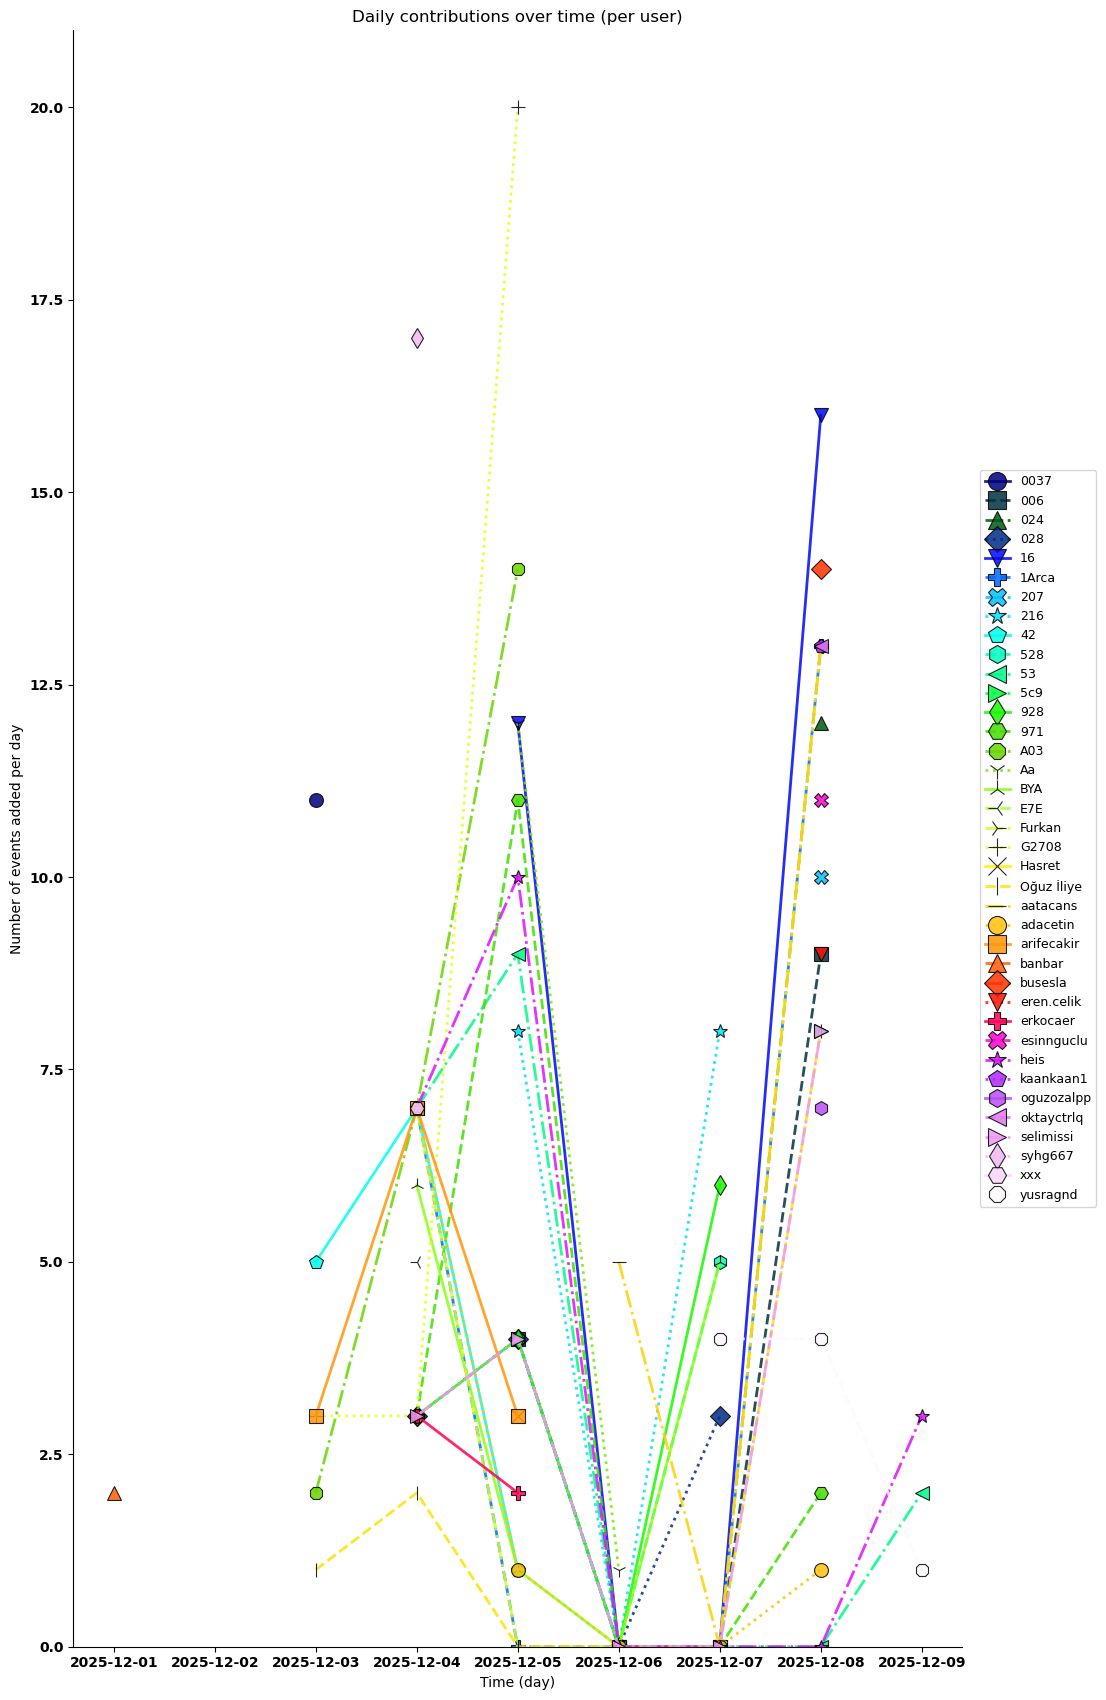

In [ ]:
# Cell 12 — Daily activity plot (X: date, Y: events added that day), one line per user
#
# Each user's line spans ONLY from their first to their last active day.
# Days with zero contributions within that range are shown as 0.

SAVE_SVG = True  # <- export this plot as SVG

# Prepare data
gdf_time = gdf.copy()
time_col_global = ensure_time_col(gdf_time)
gdf_time["_time"] = to_datetime_series(gdf_time[time_col_global])
gdf_time = gdf_time.dropna(subset=["_time"]).copy()
gdf_time["_day"] = gdf_time["_time"].dt.floor("D")

# Taller figure so legend + chart fit together and chart stays centered
n_users = len(users)
fig_h = max(8, 0.45 * n_users)
fig, ax = plt.subplots(figsize=(14, fig_h))

# Distinct color per user
cmap = plt.cm.get_cmap("tab20", n_users) if n_users <= 20 else plt.cm.get_cmap("gist_ncar", n_users)
user_colors = {u: cmap(i) for i, u in enumerate(users)}

# Wide set of distinct markers — each user gets a unique geometric shape
markers = [
    "o",   # circle
    "s",   # square
    "^",   # triangle up
    "D",   # diamond
    "v",   # triangle down
    "P",   # plus (filled)
    "X",   # x (filled)
    "*",   # star
    "p",   # pentagon
    "h",   # hexagon
    "<",   # triangle left
    ">",   # triangle right
    "d",   # thin diamond
    "H",   # rotated hexagon
    "8",   # octagon
    "1",   # tri down
    "2",   # tri up
    "3",   # tri left
    "4",   # tri right
    "+",   # plus
    "x",   # x
    "|",   # vline
    "_",   # hline
]

# Different line styles for extra differentiation when colors overlap
linestyles = ["-", "--", "-.", ":"]

for i, u in enumerate(users):
    sub = gdf_time[gdf_time[USER_COL].astype(str) == str(u)]
    if len(sub) == 0:
        continue

    # Count events per day for this user
    daily = sub.groupby("_day").size()

    # Determine user's active date range (first day to last day)
    first_day = daily.index.min()
    last_day = daily.index.max()

    # Create a complete date range between first and last day
    all_days = pd.date_range(start=first_day, end=last_day, freq="D")

    # Reindex so missing days within the range become 0
    daily_full = daily.reindex(all_days, fill_value=0)

    ax.plot(
        daily_full.index,
        daily_full.values,
        label=str(u),
        linewidth=2,
        alpha=0.85,
        color=user_colors[u],
        marker=markers[i % len(markers)],
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.8,
        linestyle=linestyles[i % len(linestyles)],
    )

# Force Y axis to start from 0
ax.set_ylim(bottom=0)

# Axis tick labels bold
ax.tick_params(axis="both", labelsize=10)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

# Axis titles normal weight
ax.set_xlabel("Time (day)", fontweight="normal")
ax.set_ylabel("Number of events added per day", fontweight="normal")
ax.set_title("Daily contributions over time (per user)")

# Remove top and right spines — keep only X and Y axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend outside, vertically centered — shows both marker and line style
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    fontsize=9,
    ncol=1,
    markerscale=1.3,
)

fig.tight_layout(rect=[0, 0, 0.80, 1])

if SAVE_SVG:
    out_path = OUTPUT_DIR / "daily_contributions.svg"
    save_plot_as_svg(fig, out_path)
    print("Saved:", out_path.resolve())

plt.show()

## Table 1: Spatial Movement & Coverage Analysis

This table evaluates users based on their **spatial discipline** and **exploration range**.  
Distances between consecutive (time-sorted) points are computed via **OSRM** route queries.

**Columns:**
- `user_id` — username
- `total_points` — total contributed data points
- `points_ge_250m` — consecutive-point pairs with OSRM distance >= 250 m (quality indicator)
- `points_lt_250m` — pairs with OSRM distance < 250 m
- `total_travel_dist` — sum of all OSRM segment distances (meters)

In [ ]:
# Cell 14 — TABLE 1: Spatial Movement & Coverage Analysis (OSRM)

MODE = "Foot"  # <- choose: "Car", "Bike", "Foot"

# Health check (OSRM has no /health endpoint — use /nearest as a ping)
try:
    test_url = OSRM_ENDPOINTS[MODE].rstrip("/") + "/nearest/v1/driving/0,0"
    r = requests.get(test_url, timeout=2)
except Exception:
    raise RuntimeError(f"Local OSRM for {MODE} is not reachable at {OSRM_ENDPOINTS[MODE]}. Run Cell 7 first.")

rows_t1 = []
for u in users:
    a = analyze_user_osrm(gdf, u, MODE)
    segs = a["segment_dists"]
    ge250 = sum(1 for d in segs if d >= MIN_DISTANCE_THRESHOLD)
    lt250 = sum(1 for d in segs if d < MIN_DISTANCE_THRESHOLD)
    rows_t1.append({
        "user_id": u,
        "total_points": a["n_points"],
        "points_ge_250m": ge250,
        "points_lt_250m": lt250,
        "total_travel_dist": round(a["sum_dist_m"], 2),
    })

df_table1 = pd.DataFrame(rows_t1).sort_values("total_travel_dist", ascending=False).reset_index(drop=True)
display(df_table1)

# --- Save as a nicely styled SVG table ---
def save_styled_table_svg(df, filepath, title="", font_size=11):
    nrows, ncols = df.shape
    fig_w = max(10, min(22, 1.4 + 1.8 * ncols))
    fig_h = max(3, 1.6 + 0.55 * (nrows + 1))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    if title:
        ax.set_title(title, pad=18, fontsize=font_size + 3, fontweight="bold", color="#2c3e50")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1.0, 1.5)

    # Style header row
    for j in range(ncols):
        cell = table[0, j]
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
        cell.set_edgecolor("white")
        cell.set_linewidth(1.5)

    # Style data rows with alternating colors
    for i in range(1, nrows + 1):
        for j in range(ncols):
            cell = table[i, j]
            cell.set_edgecolor("#dfe6e9")
            cell.set_linewidth(0.8)
            if i % 2 == 0:
                cell.set_facecolor("#f0f3f5")
            else:
                cell.set_facecolor("#ffffff")

    # Highlight top 3 rows
    medal_colors = ["#ffd70033", "#c0c0c033", "#cd7f3233"]
    for rank in range(min(3, nrows)):
        row_idx = rank + 1
        color = medal_colors[rank]
        for j in range(ncols):
            table[row_idx, j].set_facecolor(color)

    fig.tight_layout()
    fig.savefig(filepath, format="svg", bbox_inches="tight", dpi=150)
    plt.close(fig)

svg_path = Path("table1_spatial_movement.svg")
save_styled_table_svg(df_table1, svg_path, title="Table 1: Spatial Movement & Coverage Analysis")
print(f"SVG saved: {svg_path.resolve()}")

,user_id,total_points,points_ge_250m,points_lt_250m,total_travel_dist
0,53,18,8,9,10887.9
1,heis,20,6,13,10662.8
2,selimissi,15,6,8,7210.0
3,G2708,26,13,12,6440.4
4,971,16,9,6,6378.3
5,A03,23,12,10,6136.1
6,16,28,12,15,6114.7
7,028,10,6,3,5373.9
8,aatacans,18,7,10,5359.9
9,928,13,8,4,4999.0


SVG saved: C:\Users\USER\OneDrive\Resimler\Masaüstü\ISPRS_PROJECTS\DiDe\Github-DiDe\Analysis\table1_spatial_movement.svg


## Table 2: Temporal Consistency Analysis

This table assesses whether users spread their data collection across multiple days.

**Columns:**
- `user_id` — username
- `first_point_time` — earliest contribution timestamp
- `last_point_time` — latest contribution timestamp
- `daily_counts` — JSON breakdown of contributions per calendar day
- `is_3_day_rule_met` — True if user contributed on **>= 3 distinct calendar days**

In [ ]:
# Cell 16 — TABLE 2: Temporal Consistency Analysis

time_col_global = ensure_time_col(gdf)

gdf_tmp = gdf.copy()
gdf_tmp["_time"] = to_datetime_series(gdf_tmp[time_col_global])
gdf_tmp = gdf_tmp.dropna(subset=["_time"]).copy()
gdf_tmp["_day"] = gdf_tmp["_time"].dt.date

rows_t2 = []
for u in users:
    sub = gdf_tmp[gdf_tmp[USER_COL].astype(str) == str(u)]
    if len(sub) == 0:
        rows_t2.append({
            "user_id": u,
            "first_point_time": None,
            "last_point_time": None,
            "daily_counts": "{}",
            "is_3_day_rule_met": False,
        })
        continue

    first_t = sub["_time"].min()
    last_t  = sub["_time"].max()

    counts = sub.groupby("_day").size().to_dict()
    counts_json = json.dumps({str(k): int(v) for k, v in sorted(counts.items())}, ensure_ascii=False)

    unique_days = len(counts)
    is_3_day = unique_days >= 3

    rows_t2.append({
        "user_id": u,
        "first_point_time": first_t.strftime("%Y-%m-%d %H:%M:%S"),
        "last_point_time": last_t.strftime("%Y-%m-%d %H:%M:%S"),
        "daily_counts": counts_json,
        "is_3_day_rule_met": is_3_day,
    })

df_table2 = pd.DataFrame(rows_t2)
display(df_table2)

# --- Save as a nicely styled SVG table with wrapped daily_counts ---
def save_styled_table2_svg(df, filepath, title="", font_size=10):
    import textwrap

    # Rename long column header so it doesn't overflow
    df_display = df.copy()
    df_display = df_display.rename(columns={"is_3_day_rule_met": "3_day_rule"})

    # Wrap long daily_counts text so it fits inside the cell
    if "daily_counts" in df_display.columns:
        df_display["daily_counts"] = df_display["daily_counts"].apply(
            lambda x: "\n".join(textwrap.wrap(str(x), width=28))
        )

    nrows, ncols = df_display.shape

    # Count max line breaks in any cell to estimate row height
    max_lines = 1
    for val in df_display["daily_counts"]:
        lines = str(val).count("\n") + 1
        if lines > max_lines:
            max_lines = lines

    # Wider figure to prevent overflow
    fig_w = max(20, min(30, 2.0 + 2.5 * ncols))
    row_height = 0.50 + 0.22 * (max_lines - 1)
    fig_h = max(5, 2.5 + row_height * (nrows + 1))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    # Title ABOVE the table with enough padding so it doesn't overlap
    if title:
        fig.suptitle(title, fontsize=font_size + 4, fontweight="bold", color="#2c3e50", y=0.98)

    table = ax.table(
        cellText=df_display.values,
        colLabels=df_display.columns,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)

    # Set custom column widths — wider overall
    col_widths = {}
    for j, col in enumerate(df_display.columns):
        if col == "daily_counts":
            col_widths[j] = 0.28
        elif col in ("first_point_time", "last_point_time"):
            col_widths[j] = 0.17
        elif col == "3_day_rule":
            col_widths[j] = 0.10
        elif col == "user_id":
            col_widths[j] = 0.10
        else:
            col_widths[j] = 0.12

    # Apply column widths and row heights
    for i in range(nrows + 1):
        for j in range(ncols):
            cell = table[i, j]
            cell.set_width(col_widths.get(j, 0.12))
            if i == 0:
                cell.set_height(0.055)
            else:
                cell.set_height(0.04 + 0.016 * max_lines)

    # Style header row
    for j in range(ncols):
        cell = table[0, j]
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold", fontsize=font_size)
        cell.set_edgecolor("white")
        cell.set_linewidth(1.5)

    # Style data rows with alternating colors
    for i in range(1, nrows + 1):
        for j in range(ncols):
            cell = table[i, j]
            cell.set_edgecolor("#dfe6e9")
            cell.set_linewidth(0.8)
            cell.set_text_props(fontsize=font_size - 1)

            if i % 2 == 0:
                cell.set_facecolor("#f0f3f5")
            else:
                cell.set_facecolor("#ffffff")

            # Highlight 3_day_rule with color
            col_name = df_display.columns[j]
            if col_name == "3_day_rule":
                val = df_display.iloc[i - 1, j]
                if val is True or str(val).strip() == "True":
                    cell.set_text_props(color="#27ae60", fontweight="bold", fontsize=font_size - 1)
                else:
                    cell.set_text_props(color="#e74c3c", fontweight="bold", fontsize=font_size - 1)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(filepath, format="svg", bbox_inches="tight", dpi=150)
    plt.close(fig)

svg_path = Path("table2_temporal_consistency.svg")
save_styled_table2_svg(df_table2, svg_path)
print(f"SVG saved: {svg_path.resolve()}")

,user_id,first_point_time,last_point_time,daily_counts,is_3_day_rule_met
0,0037,2025-12-03 09:40:57,2025-12-03 11:52:59,"{""2025-12-03"": 11}",False
1,006,2025-12-05 09:44:29,2025-12-08 09:38:21,"{""2025-12-05"": 4, ""2025-12-08"": 9}",False
2,024,2025-12-08 06:14:09,2025-12-08 06:40:44,"{""2025-12-08"": 12}",False
3,028,2025-12-04 12:34:37,2025-12-07 14:12:36,"{""2025-12-04"": 3, ""2025-12-05"": 4, ""2025-12-07...",True
4,16,2025-12-05 11:30:48,2025-12-08 13:47:41,"{""2025-12-05"": 12, ""2025-12-08"": 16}",False
5,1Arca,2025-12-04 10:41:30,2025-12-08 13:03:42,"{""2025-12-04"": 7, ""2025-12-08"": 13}",False
6,207,2025-12-08 11:01:10,2025-12-08 13:48:58,"{""2025-12-08"": 10}",False
7,216,2025-12-05 10:09:14,2025-12-07 14:26:04,"{""2025-12-05"": 8, ""2025-12-07"": 8}",False
8,42,2025-12-03 06:32:52,2025-12-05 09:47:24,"{""2025-12-03"": 5, ""2025-12-04"": 7, ""2025-12-05...",True
9,528,2025-12-05 10:14:52,2025-12-07 14:23:34,"{""2025-12-05"": 4, ""2025-12-07"": 5}",False


C:\Users\USER\AppData\Local\Temp\ipykernel_4980\2869770980.py:142: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


SVG saved: C:\Users\USER\OneDrive\Resimler\Masaüstü\ISPRS_PROJECTS\DiDe\Github-DiDe\Analysis\table2_temporal_consistency.svg


## Table 3: Image Contribution Analysis

This table shows how many **images** each user contributed (for "Cigarette Butt" events).  
Only the image count per user is reported.

In [ ]:
# Cell 18 — TABLE 3: Image Contribution (Image_Count only)

# Count images per user from the GeoJSON photo_urls field
# Only count events of type "Cigarette Butt" (if the column exists)

gdf_img = gdf.copy()

# Filter to cigarette butt events if the event type column exists
if EVENT_TYPE_COL in gdf_img.columns:
    gdf_img = gdf_img[gdf_img[EVENT_TYPE_COL] == CIG_EVENT_NAME].copy()

rows_t3 = []
for u in users:
    sub = gdf_img[gdf_img[USER_COL].astype(str) == str(u)]
    img_count = 0
    for _, row in sub.iterrows():
        urls = parse_photo_urls(row.get(PHOTO_COL))
        img_count += len(urls)
    rows_t3.append({
        "user_id": u,
        "Image_Count": img_count,
    })

df_table3 = pd.DataFrame(rows_t3).sort_values("Image_Count", ascending=False).reset_index(drop=True)
display(df_table3)

# --- Save as a nicely styled SVG table ---
def save_styled_table3_svg(df, filepath, title="", font_size=11):
    nrows, ncols = df.shape
    fig_w = max(8, min(14, 1.4 + 2.5 * ncols))
    fig_h = max(4, 2.5 + 0.5 * (nrows + 1))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    # Title above the table with enough padding
    if title:
        fig.suptitle(title, fontsize=font_size + 4, fontweight="bold", color="#2c3e50", y=0.98)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1.0, 1.5)

    # Style header row
    for j in range(ncols):
        cell = table[0, j]
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold", fontsize=font_size)
        cell.set_edgecolor("white")
        cell.set_linewidth(1.5)

    # Style data rows with alternating colors
    for i in range(1, nrows + 1):
        for j in range(ncols):
            cell = table[i, j]
            cell.set_edgecolor("#dfe6e9")
            cell.set_linewidth(0.8)
            cell.set_text_props(fontsize=font_size)

            if i % 2 == 0:
                cell.set_facecolor("#f0f3f5")
            else:
                cell.set_facecolor("#ffffff")

        # Color-code Image_Count column with gradient (higher = darker green)
        img_col_idx = list(df.columns).index("Image_Count")
        val = df.iloc[i - 1, img_col_idx]
        max_val = df["Image_Count"].max()

        if max_val > 0 and val > 0:
            intensity = val / max_val
            # Green gradient: 0 → white, max → dark green
            r_c = int(255 - intensity * 130)
            g_c = int(255 - intensity * 40)
            b_c = int(255 - intensity * 130)
            cell_color = f"#{r_c:02x}{g_c:02x}{b_c:02x}"
            table[i, img_col_idx].set_facecolor(cell_color)
            if intensity > 0.6:
                table[i, img_col_idx].set_text_props(
                    color="white", fontweight="bold", fontsize=font_size
                )

    # Highlight top 3 rows
    medal_colors = ["#ffd70033", "#c0c0c033", "#cd7f3233"]
    for rank in range(min(3, nrows)):
        row_idx = rank + 1
        color = medal_colors[rank]
        for j in range(ncols):
            # Don't override Image_Count gradient for top rows
            if j != img_col_idx:
                table[row_idx, j].set_facecolor(color)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(filepath, format="svg", bbox_inches="tight", dpi=150)
    plt.close(fig)

svg_path = Path("table3_image_contribution.svg")
save_styled_table3_svg(df_table3, svg_path, title="Table 3: Image Contribution Analysis")
print(f"SVG saved: {svg_path.resolve()}")

,user_id,Image_Count
0,G2708,20
1,A03,19
2,16,18
3,selimissi,13
4,arifecakir,11
5,heis,8
6,adacetin,8
7,207,8
8,oguzozalpp,7
9,5c9,7


SVG saved: C:\Users\USER\OneDrive\Resimler\Masaüstü\ISPRS_PROJECTS\DiDe\Github-DiDe\Analysis\table3_image_contribution.svg


## Comprehensive Scoring System (0 – 100 Points)

The evaluation framework distributes **100 points** across three categories:

### 1. Spatial Discipline Score (40 points)
- **Distance Efficiency (25 pts):** Rewards users who maintain >= 250 m spacing between consecutive points.  
  `score = (points_ge_250m / max(points_ge_250m)) * 25`
- **Exploration Distance (15 pts):** Based on total OSRM travel distance.  
  `score = (total_travel_dist / max(total_travel_dist)) * 15`

### 2. Temporal Continuity Score (30 points)
- **3-Day Rule Bonus (30 pts):** Full 30 points awarded if the user contributed data on **>= 3 distinct calendar days**; otherwise 0.

### 3. Image Analysis Score (30 points)
- **Image Contribution (30 pts):** Based on the number of images submitted.  
  `score = (Image_Count / max(Image_Count)) * 30`

Each sub-score uses **ratio normalization** (value / max across all users).  
Final Score = Spatial Score + Temporal Score + Image Score

In [ ]:
# Cell 20 — FINAL SCORING TABLE

# Build a merged scoring dataframe from Tables 1, 2, 3
df_score = df_table1[["user_id", "points_ge_250m", "total_travel_dist"]].copy()
df_score = df_score.merge(
    df_table2[["user_id", "is_3_day_rule_met"]], on="user_id", how="left"
)
df_score = df_score.merge(
    df_table3[["user_id", "Image_Count"]], on="user_id", how="left"
)
df_score["Image_Count"] = df_score["Image_Count"].fillna(0).astype(int)

# --- Spatial Discipline Score (40 pts) ---
max_ge250 = df_score["points_ge_250m"].max()
max_dist  = df_score["total_travel_dist"].max()

df_score["distance_efficiency_25"] = (
    (df_score["points_ge_250m"] / max_ge250 * 25.0) if max_ge250 > 0
    else 0.0
)
df_score["exploration_distance_15"] = (
    (df_score["total_travel_dist"] / max_dist * 15.0) if max_dist > 0
    else 0.0
)
df_score["spatial_score"] = (
    df_score["distance_efficiency_25"] + df_score["exploration_distance_15"]
).round(2)

# --- Temporal Continuity Score (30 pts) ---
df_score["temporal_score"] = df_score["is_3_day_rule_met"].apply(
    lambda x: 30.0 if x else 0.0
)

# --- Image Analysis Score (30 pts) ---
max_img = df_score["Image_Count"].max()
df_score["image_score"] = (
    (df_score["Image_Count"] / max_img * 30.0) if max_img > 0
    else 0.0
).round(2)

# --- Total ---
df_score["total_score"] = (
    df_score["spatial_score"] + df_score["temporal_score"] + df_score["image_score"]
).round(2)

# Prepare display table
df_final = df_score[[
    "user_id", "spatial_score", "temporal_score", "image_score", "total_score"
]].sort_values("total_score", ascending=False).reset_index(drop=True)

df_final.insert(0, "Rank", range(1, len(df_final) + 1))

display(Markdown("### Final Rankings"))
display(df_final)

# --- Save as a clean styled SVG table ---
def save_final_scoring_svg(df, filepath, title="", font_size=11):
    nrows, ncols = df.shape
    fig_w = max(12, min(20, 1.4 + 2.0 * ncols))
    fig_h = max(4, 2.5 + 0.5 * (nrows + 1))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    if title:
        fig.suptitle(title, fontsize=font_size + 3, fontweight="bold", color="#2c3e50", y=0.98)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1.0, 1.5)

    # Header row
    for j in range(ncols):
        cell = table[0, j]
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
        cell.set_edgecolor("white")
        cell.set_linewidth(1.5)

    # Data rows — clean alternating colors
    for i in range(1, nrows + 1):
        for j in range(ncols):
            cell = table[i, j]
            cell.set_edgecolor("#dfe6e9")
            cell.set_linewidth(0.8)

            if i % 2 == 0:
                cell.set_facecolor("#f0f3f5")
            else:
                cell.set_facecolor("#ffffff")

    # Bold total_score column
    total_col_idx = list(df.columns).index("total_score")
    for i in range(1, nrows + 1):
        table[i, total_col_idx].set_text_props(fontweight="bold")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(filepath, format="svg", bbox_inches="tight", dpi=150)
    plt.close(fig)

svg_path = Path("final_scoring.svg")
save_final_scoring_svg(df_final, svg_path, title="Final Scoring (Spatial 40 + Temporal 30 + Image 30 = 100)")
print(f"SVG saved: {svg_path.resolve()}")

# Print scoring criteria summary
print()
print("=" * 70)
print("SCORING CRITERIA")
print("=" * 70)
print("Spatial Discipline Score  (40 pts)")
print("  - Distance Efficiency   (25 pts): points_ge_250m / max * 25")
print("  - Exploration Distance  (15 pts): total_travel_dist / max * 15")
print()
print("Temporal Continuity Score (30 pts)")
print("  - 3-Day Rule Bonus      (30 pts): 30 if >= 3 unique days, else 0")
print()
print("Image Analysis Score      (30 pts)")
print("  - Image Contribution    (30 pts): Image_Count / max * 30")
print("=" * 70)

### Final Rankings

,Rank,user_id,spatial_score,temporal_score,image_score,total_score
0,1,G2708,33.87,30.0,30.0,93.87
1,2,A03,31.53,30.0,28.5,90.03
2,3,selimissi,21.47,30.0,19.5,70.97
3,4,53,30.38,30.0,10.5,70.88
4,5,heis,26.23,30.0,12.0,68.23
5,6,971,26.09,30.0,10.5,66.59
6,7,BYA,27.45,30.0,9.0,66.45
7,8,arifecakir,18.84,30.0,16.5,65.34
8,9,16,31.50,0.0,27.0,58.50
9,10,928,22.27,30.0,6.0,58.27


SVG saved: C:\Users\USER\OneDrive\Resimler\Masaüstü\ISPRS_PROJECTS\DiDe\Github-DiDe\Analysis\final_scoring.svg

SCORING CRITERIA
Spatial Discipline Score  (40 pts)
  - Distance Efficiency   (25 pts): points_ge_250m / max * 25
  - Exploration Distance  (15 pts): total_travel_dist / max * 15

Temporal Continuity Score (30 pts)
  - 3-Day Rule Bonus      (30 pts): 30 if >= 3 unique days, else 0

Image Analysis Score      (30 pts)
  - Image Contribution    (30 pts): Image_Count / max * 30
